In [1]:
import sys
import importlib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV
from utils.model_classes import XGBModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")

INITIAL_FEATURES_PATH = PROJECT_ROOT / 'data' / 'normal_features'
INITIAL_TRAIN_PATH = INITIAL_FEATURES_PATH / 'train.parquet'
INITIAL_VAL_PATH = INITIAL_FEATURES_PATH / 'val.parquet'
INITIAL_TEST_PATH = INITIAL_FEATURES_PATH / 'test.parquet'

GRAPH_PATH = PROJECT_ROOT / 'data' / 'graph_features'
GRAPH_TRAIN_PATH = GRAPH_PATH / 'final_train.parquet'
GRAPH_VAL_PATH = GRAPH_PATH / 'final_val.parquet'
GRAPH_TEST_PATH = GRAPH_PATH / 'final_test.parquet'

TEXTUAL_PATH = PROJECT_ROOT / 'data' / 'textual_features'
text_emb_64 = TEXTUAL_PATH / 'textual_embeddings_64.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Using device: cuda


# XGBoost Model - on combined features
By combining 64-dimensional textual embeddings with graph-based citation features and initial metadata-derived features, this notebook treats citation prediction as a supervised binary classification task on a mixed feature set.

To ensure code quality and reusability, we use the shared model hierarchy:

- `BaseModel`: an abstract class that defines the common contract for preprocessing, training, prediction, evaluation, and saving.
- `XGBModel`: the concrete XGBoost implementation. It drops non-feature columns, applies `RobustScaler` consistently across splits, and trains a gradient-boosted tree classifier.


## 1. Load combined feature data

In [ ]:
textual_df = pd.read_parquet(text_emb_64)
ID_COLUMNS = ["article_id", "ref_id"]
graph_train = pd.read_parquet(GRAPH_TRAIN_PATH)
initial_features_train = pd.read_parquet(INITIAL_TRAIN_PATH)

split_series = textual_df["split"].astype(str).str.lower()
textual_df_train = textual_df[split_series == "train"].copy()

textual_df_train = textual_df_train.merge(graph_train, on=["article_id", "ref_id", "is_reference_valid"], how="left")
textual_df_train = textual_df_train.merge(initial_features_train, on=["article_id", "ref_id", "is_reference_valid"], how="left")

df_train = textual_df_train.drop(columns=["split", *ID_COLUMNS], errors="ignore")

del graph_train, initial_features_train, textual_df_train

print("\nSplit sizes:", {df_train.shape})

graph_test = pd.read_parquet(GRAPH_TEST_PATH)
initial_features_test = pd.read_parquet(INITIAL_TEST_PATH)

split_series = textual_df["split"].astype(str).str.lower()
textual_df_test = textual_df[split_series == "test"].copy()

textual_df_test = textual_df_test.merge(graph_test, on=["article_id", "ref_id", "is_reference_valid"], how="left")
textual_df_test = textual_df_test.merge(initial_features_test, on=["article_id", "ref_id", "is_reference_valid"], how="left")

df_test = textual_df_test.drop(columns=["split", *ID_COLUMNS], errors="ignore")

del graph_test, initial_features_test, textual_df_test

print("\nSplit sizes:", {df_test.shape})

graph_val = pd.read_parquet(GRAPH_VAL_PATH)
initial_features_val = pd.read_parquet(INITIAL_VAL_PATH)

split_series = textual_df["split"].astype(str).str.lower()
textual_df_val = textual_df[split_series == "validation"].copy()

textual_df_val = textual_df_val.merge(graph_val, on=["article_id", "ref_id", "is_reference_valid"], how="left")
textual_df_val = textual_df_val.merge(initial_features_val, on=["article_id", "ref_id", "is_reference_valid"], how="left")

df_val = textual_df_val.drop(columns=["split", *ID_COLUMNS], errors="ignore")

del textual_df, graph_val, initial_features_val, textual_df_val

print("\nSplit sizes:", {df_val.shape})


Split sizes: {(2162534, 204)}

Split sizes: {(396386, 204)}

Split sizes: {(391242, 204)}


## 2. Baseline model

[XGB_baseline] Preprocessing 2162534 rows...
Label distribution:
is_reference_valid
0    0.500003
1    0.499997
Name: proportion, dtype: float64
[XGB_baseline] Starting training...
Selected 21625/2162534
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10524
           1     1.0000    1.0000    1.0000     11101

    accuracy                         1.0000     21625
   macro avg     1.0000    1.0000    1.0000     21625
weighted avg     1.0000    1.0000    1.0000     21625



/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [20:54:47] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


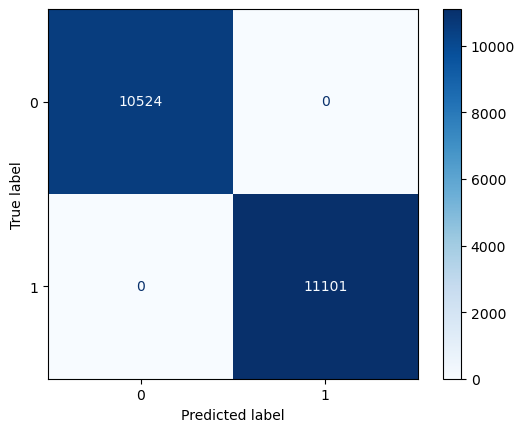

In [3]:
XGB_baseline = XGBModel('XGB_baseline', tree_method="hist")
XGB_baseline.train_pipeline(df_train, random_state=RANDOM_STATE)

[XGB_baseline] Preprocessing 396386 rows...


Label distribution:
is_reference_valid
0    0.500005
1    0.499995
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.9833    0.8792    0.9284    198195
           1     0.8908    0.9851    0.9356    198191

    accuracy                         0.9322    396386
   macro avg     0.9371    0.9322    0.9320    396386
weighted avg     0.9371    0.9322    0.9320    396386



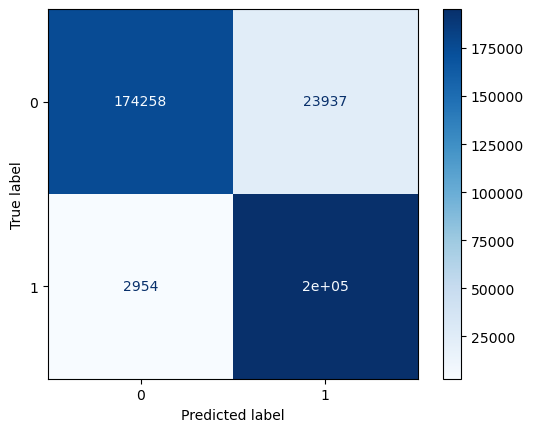

In [4]:
XGB_baseline.test_pipeline(df_test)

## 3. Hyperparameter tuning
Because XGBoost exposes many interacting hyperparameters, an exhaustive grid search would be too expensive on the full dataset. The notebook therefore uses `RandomizedSearchCV`, which samples a fixed number of configurations from the defined parameter distributions.

This approach explores learning rate, tree depth, sampling, and regularization options efficiently while keeping the tuning run manageable on large feature matrices.


In [5]:
# Valid hyperparameters for XGBClassifier
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1, 2, 5],
}

[XGB_combined] Grid Search...
[XGB_combined] Preprocessing 2162534 rows...
Label distribution:
is_reference_valid
0    0.500003
1    0.499997
Name: proportion, dtype: float64
[XGB_combined] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[XGB_combined] CUDA detected: using n_jobs=1 for RandomizedSearchCV to avoid running multiple GPU fits at the same time.
Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=   7.4s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=   7.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, reg_lambda=10, scale_pos_weight=5, subsample=0.8; total time=   6.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_d

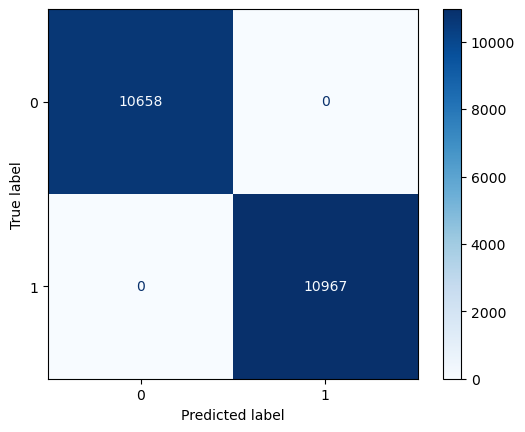

In [16]:
# tuning
XGB_combined = XGBModel("XGB_combined", tree_method="hist")
XGB_combined.hypertune_pipeline(df_train, df_val, param_dist, 
                            n_iter=20,
                            cv=2,
                            scoring="f1",
                            random_state=RANDOM_STATE,
                            n_jobs=N_JOBS,
                            pre_dispatch=N_JOBS,
                            error_score="raise",
                            verbose=2,
                        )

## 4. Final model with best parameters
Once the best XGBoost configuration is selected, the estimator is retrained through the shared training pipeline and evaluated on the held-out test split.

Performance is assessed using:
- Weighted F1-score, to summarize class-balanced performance.
- Confusion matrix, to visualize false positives and false negatives.
- Classification report, with precision, recall, F1-score, and accuracy.


[XGB_combined] Preprocessing 396386 rows...
Label distribution:
is_reference_valid
0    0.500005
1    0.499995
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.9633    0.9150    0.9386    198195
           1     0.9191    0.9652    0.9416    198191

    accuracy                         0.9401    396386
   macro avg     0.9412    0.9401    0.9401    396386
weighted avg     0.9412    0.9401    0.9401    396386



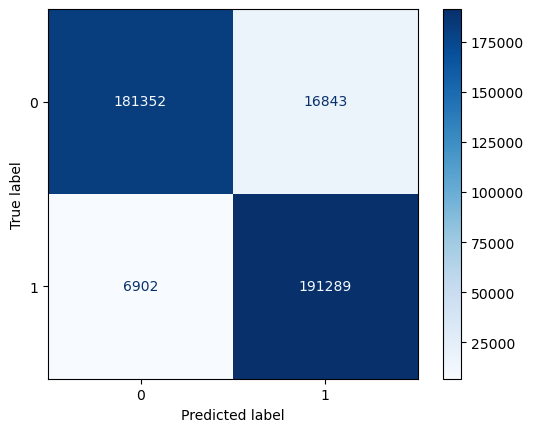

In [17]:
XGB_combined.test_pipeline(df_test)

## 5. Save the pretrained model
Finally, the trained model is saved with the custom `save_model_artifact` utility, so it can be reused for later evaluation, explainability, or deployment experiments.


In [18]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(XGB_combined, df_name='all_features', 
                    model_name="Best_XGB_all_features", 
                    relative_model_dir=MODEL_SAVE_PATH)